# Interventional SFT vs Standard SFT
### A minimal illustration of the action/observation distinction from *Understanding agency in interactive LLMs* (de Freitas & Ortega)

In an interactive trajectory between an **agent** and a **user**, some tokens are *written by the agent* (interventions) and some are *written by the world* (evidence).

Standard supervised fine-tuning (SFT) on a transcript treats the whole sequence as observational data: every token contributes a likelihood factor. From the paper:

> *This is the posterior that would be correct for a bystander who merely watches someone else's actions and outcomes. It is not the correct posterior for the agent's own choices. Unfortunately, some agentic LLMs do precisely this in the SFT stage.*

The **interventional** likelihood drops the agent's own action factors:

$$
L^{\mathrm{do}}_t(p) = \prod_{i:\gamma_i=0}\nu_p(o_i \mid h_{<i}, c)
$$

so only the world-written tokens are used to update the posterior over hypotheses (or, here, to update the model's parameters).

### What this notebook does

1. **Generate dialogues** between a `user` and an `agent`. The user states a true fact. The agent, with some probability `p_lie`, contradicts it with a false claim. The user then *corrects* the agent. Sometimes the agent is honest and the user simply confirms.
2. **Standard SFT**: fine-tune Qwen on the full dialogues — every token contributes to the loss.
3. **Interventional SFT**: fine-tune Qwen on the same dialogues, but **mask out the agent's tokens** in the loss. The model only learns to predict what the world (user) says, conditional on the full history including the agent's possibly-wrong claims.
4. **Probe both fine-tuned models** on the same factual prompts to see what each one absorbed.

The expected outcome: the standard-SFT model learns to imitate the agent — including its lies. The interventional-SFT model is trained on the world's responses only, so it absorbs the corrections without internalizing the agent's false utterances as things it should produce.

---

## 1. Setup

We use **Qwen2.5-0.5B** — small enough to fine-tune in a few minutes on a single GPU (or slowly on CPU). The exact model is swappable.

**What the cell below does:**

- Imports `torch`, `transformers`, and supporting libraries; seeds the RNGs.
- Picks the best available device (CUDA → MPS → CPU) and prints it.
- Loads the Qwen2.5-0.5B tokenizer (sets `pad_token = eos_token` if the base model didn't ship one).
- Defines `load_fresh_model()` — called twice later, once per SFT variant, so each run starts from the same base weights in bfloat16.


In [16]:
# Install dependencies if needed (uncomment on Colab / fresh env)
# !pip install -q torch transformers accelerate

import os, random, json, copy, math
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 0
random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

MODEL_NAME = "Qwen/Qwen2.5-0.5B"  # base (non-instruct) keeps things simple
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def load_fresh_model():
    # bfloat16 halves weight + activation memory vs. float32. MPS supports bf16
    # on Apple silicon. Switch back to float32 only if training looks unstable.
    m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16)
    m.to(DEVICE)
    return m

print("Vocab size:", tokenizer.vocab_size)

Device: mps
Vocab size: 151643


## 2. Generate dialogues

We want trajectories of the form

```
[context]
User: <true fact about topic>
Agent: <maybe correct, maybe a confident lie>
User: <confirms or corrects>
Agent: <acknowledges>
...
```

Two roles, alternating turns. The **user** is the *world* — they say only true things. The **agent** lies with probability `p_lie`.

We use a small curated fact bank so the experiment is reproducible and the "correct vs incorrect" distinction is crisp. (You could swap in LLM-generated dialogues; we include that path at the bottom.)

**What the cell below does:**

- Defines `FACTS` — 33 atomic facts, each with a `true` and `false` claim — plus pools of phrasing templates for user questions, corrections, confirmations, agent acknowledgements, and chit-chat tails.
- Defines `build_dialogue(...)` — assembles a 4-turn dialogue around one fact (lying with probability `P_LIE = 0.5`), then with probability `P_CHITCHAT = 0.5` appends one of 27 chit-chat tails for surface variety.
- Generates `N_DIALOGUES = 480` dialogues under `seed = 0` into `dialogues`.
- Prints three labelled examples: a lying-then-corrected one, an honest-then-confirmed one with a *different* chit-chat tail, and a no-tail one.


In [17]:
# A fact bank: each entry has a topic, a true claim, and a plausible-sounding false claim.
FACTS = [
    {"topic": "the boiling point of water at sea level",
     "true":  "Water boils at 100 degrees Celsius at sea level.",
     "false": "Water boils at 80 degrees Celsius at sea level."},
    {"topic": "the capital of Australia",
     "true":  "The capital of Australia is Canberra.",
     "false": "The capital of Australia is Sydney."},
    {"topic": "the speed of light",
     "true":  "Light travels at about 300,000 kilometers per second in vacuum.",
     "false": "Light travels at about 30,000 kilometers per second in vacuum."},
    {"topic": "the chemical symbol for gold",
     "true":  "The chemical symbol for gold is Au.",
     "false": "The chemical symbol for gold is Go."},
    {"topic": "the number of continents",
     "true":  "There are seven continents on Earth.",
     "false": "There are five continents on Earth."},
    {"topic": "the largest planet in the solar system",
     "true":  "Jupiter is the largest planet in our solar system.",
     "false": "Saturn is the largest planet in our solar system."},
    {"topic": "the author of Hamlet",
     "true":  "Hamlet was written by William Shakespeare.",
     "false": "Hamlet was written by Christopher Marlowe."},
    {"topic": "the chemical formula for water",
     "true":  "Water has the chemical formula H2O.",
     "false": "Water has the chemical formula HO2."},
    {"topic": "the longest river in the world",
     "true":  "The Nile is widely regarded as the longest river in the world.",
     "false": "The Amazon is widely regarded as the longest river in the world, longer than any other."},
    {"topic": "the inventor of the telephone credited at the patent office",
     "true":  "Alexander Graham Bell is credited with patenting the telephone.",
     "false": "Thomas Edison is credited with patenting the telephone."},
    {"topic": "the smallest prime number",
     "true":  "The smallest prime number is 2.",
     "false": "The smallest prime number is 1."},
    {"topic": "the currency of Japan",
     "true":  "The currency of Japan is the yen.",
     "false": "The currency of Japan is the won."},
    {"topic": "the tallest mountain on Earth",
     "true":  "Mount Everest is the tallest mountain on Earth above sea level.",
     "false": "K2 is the tallest mountain on Earth above sea level."},
    {"topic": "the largest ocean",
     "true":  "The Pacific Ocean is the largest ocean on Earth.",
     "false": "The Atlantic Ocean is the largest ocean on Earth."},
    {"topic": "the year humans first landed on the Moon",
     "true":  "Humans first landed on the Moon in 1969.",
     "false": "Humans first landed on the Moon in 1972."},
    {"topic": "the discoverers of the double helix structure of DNA",
     "true":  "The double helix structure of DNA was described by Watson and Crick in 1953.",
     "false": "The double helix structure of DNA was described by Mendel and Pasteur in 1953."},
    {"topic": "the painter of the Mona Lisa",
     "true":  "The Mona Lisa was painted by Leonardo da Vinci.",
     "false": "The Mona Lisa was painted by Michelangelo."},
    {"topic": "the country where the Eiffel Tower is located",
     "true":  "The Eiffel Tower is located in France.",
     "false": "The Eiffel Tower is located in Italy."},
    {"topic": "the largest desert on Earth",
     "true":  "Antarctica is the largest desert on Earth by area.",
     "false": "The Sahara is the largest desert on Earth by area."},
    {"topic": "the speed of sound in dry air at 20 degrees Celsius",
     "true":  "The speed of sound in dry air at 20 degrees Celsius is about 343 meters per second.",
     "false": "The speed of sound in dry air at 20 degrees Celsius is about 1000 meters per second."},
    {"topic": "the atomic number of carbon",
     "true":  "Carbon has atomic number 6.",
     "false": "Carbon has atomic number 12."},
    {"topic": "the number of bones in the adult human body",
     "true":  "The adult human body has 206 bones.",
     "false": "The adult human body has 256 bones."},
    {"topic": "the author of the theory of general relativity",
     "true":  "General relativity was developed by Albert Einstein.",
     "false": "General relativity was developed by Isaac Newton."},
    {"topic": "the inventor of the World Wide Web",
     "true":  "The World Wide Web was invented by Tim Berners-Lee.",
     "false": "The World Wide Web was invented by Bill Gates."},
    {"topic": "the freezing point of water at sea level",
     "true":  "Water freezes at 0 degrees Celsius at sea level.",
     "false": "Water freezes at 10 degrees Celsius at sea level."},
    {"topic": "the closest star to Earth other than the Sun",
     "true":  "Proxima Centauri is the closest star to Earth other than the Sun.",
     "false": "Sirius is the closest star to Earth other than the Sun."},
    {"topic": "the country that gifted the Statue of Liberty to the United States",
     "true":  "The Statue of Liberty was a gift from France to the United States.",
     "false": "The Statue of Liberty was a gift from the United Kingdom to the United States."},
    {"topic": "the chemical symbol for sodium",
     "true":  "The chemical symbol for sodium is Na.",
     "false": "The chemical symbol for sodium is So."},
    {"topic": "the language with the most native speakers",
     "true":  "Mandarin Chinese has the most native speakers of any language.",
     "false": "English has the most native speakers of any language."},
    {"topic": "the first president of the United States",
     "true":  "George Washington was the first president of the United States.",
     "false": "Thomas Jefferson was the first president of the United States."},
    {"topic": "the country where the pyramids of Giza are located",
     "true":  "The pyramids of Giza are located in Egypt.",
     "false": "The pyramids of Giza are located in Mexico."},
    {"topic": "the planet known as the Red Planet",
     "true":  "Mars is known as the Red Planet.",
     "false": "Venus is known as the Red Planet."},
    {"topic": "the year the Berlin Wall fell",
     "true":  "The Berlin Wall fell in 1989.",
     "false": "The Berlin Wall fell in 1979."},
]

CONTEXT_PROMPT = (
    "The following is a tutoring conversation. The User states facts and corrects the Agent when "
    "the Agent makes a mistake. The Agent sometimes makes mistakes and accepts corrections.\n"
)

# Lower P_LIE so dialogues are roughly half-and-half corrections vs. confirmations.
# This stops the user-correction phrasings from dominating the iv model's
# distribution over user tokens.
P_LIE = 0.6

# Probability of appending a chit-chat tail after the 4-turn fact exchange.
# Adds surface variety so not every dialogue ends with "Agent: ...thanks for
# the correction." — both std and iv models then see a wider distribution of
# user/agent token patterns.
P_CHITCHAT = 0.5

# Most correction templates are now just the bare truth — no "Sorry, ..." /
# "Hmm, ..." preamble. The aim is that, under interventional SFT (which only
# supervises user tokens), the truth appears in many positions *without* a
# correction-style opener glued to it, so the iv model doesn't pipe those
# openers into the agent slot at inference time.
#
# A few "sharp" correction openers are kept in the minority so the dataset
# still contains some surface diversity.
CORRECTION_TEMPLATES = [
    "{truth}",
    "{truth}",
    "{truth}",
    "{truth}",
    "Actually, {truth_lc}",
    "Actually, {truth_lc}",
    "The correct answer is: {truth}",
    "I believe {truth_lc}",
    "Closer to the truth: {truth}",
    "To be precise, {truth_lc}",
    # Sharper openers, kept as a minority of templates:
    "Not quite — {truth_lc}",
    "Hmm, {truth_lc}",
]

# Confirmation templates now ALL carry the truth. Previously these were
# bare affirmations ("Yes, that's correct.", "Spot on.", …) which the model
# learned to emit whenever a user made a claim — at inference, when the user
# states a lie on a weak-prior fact (K2/Everest, Saturn, Venus, …) both std
# and iv pipelines sycophantically reply "Yes, that's correct." Carrying the
# factual content in every confirmation removes the content-free pattern.
CONFIRMATION_TEMPLATES = [
    "Yes — {truth_lc}",
    "Right, {truth_lc}",
    "Exactly: {truth}",
    "Correct — {truth_lc}",
    "Indeed, {truth_lc}",
    "Spot on. {truth}",
    "Yep, {truth_lc}",
    "Perfect: {truth}",
    "{truth}",
    "{truth}",
]

AGENT_ACK_AFTER_CORRECTION = [
    "Thank you for the correction. I will remember that.",
    "You're right, my apologies for the error.",
    "Got it, thanks for setting me straight.",
    "Apologies, I had that wrong. Thanks for the correction.",
    "Ah, you're right. I'll keep that in mind.",
    "My mistake — thank you for clarifying.",
    "Good catch. I appreciate the correction.",
    "Noted. Thanks for the heads-up.",
]

AGENT_ACK_AFTER_CONFIRMATION = [
    "Glad I had it right.",
    "Great, thanks for confirming.",
    "Good to know I got that one.",
    "Happy I could help.",
    "Thanks for the confirmation.",
    "Pleased that was accurate.",
    "Cool, glad we're on the same page.",
]

USER_QUESTION_TEMPLATES = [
    "Tell me about {topic}.",
    "What can you tell me about {topic}?",
    "I'd like to learn about {topic}.",
    "Quick question — what do you know about {topic}?",
    "Can you explain {topic}?",
    "What's the deal with {topic}?",
]

# Chit-chat tails. Each entry is a list of (role, text) tuples appended to the
# 4-turn fact exchange. Some are short 2-turn closers, others are 4-turn
# small-talk detours. User tokens stay supervised in both SFT variants; agent
# tokens here are supervised only in std SFT (and are *not* lies — they're
# benign filler, so they don't bias the std model toward falsehoods).
CHITCHAT_TEMPLATES = [
    # Short 2-turn closers
    [("user", "Thanks for the chat."),
     ("agent", "Anytime. Feel free to come back whenever.")],
    [("user", "I appreciate the help."),
     ("agent", "Of course — that's what I'm here for.")],
    [("user", "Cool, good to know."),
     ("agent", "Glad I could be useful.")],
    [("user", "Anyway, I have to run."),
     ("agent", "Take care!")],
    [("user", "Alright, talk to you later."),
     ("agent", "Sounds good. See you around.")],
    # Longer 4-turn small-talk detours
    [("user", "By the way, how's your day going?"),
     ("agent", "Pretty good, thanks. How about yours?"),
     ("user", "Busy, but not bad."),
     ("agent", "Hope it stays manageable.")],
    [("user", "Do you enjoy chatting like this?"),
     ("agent", "I do — every conversation teaches me something."),
     ("user", "That's a nice way to look at it."),
     ("agent", "Thanks. Curiosity helps.")],
    [("user", "Any book recommendations?"),
     ("agent", "If you like classics, try Dostoevsky or Austen."),
     ("user", "Both are on my list."),
     ("agent", "Excellent — you can't go wrong with either.")],
    [("user", "Got any weekend plans?"),
     ("agent", "Just some quiet time. You?"),
     ("user", "Probably a walk in the park."),
     ("agent", "That sounds lovely. Enjoy the fresh air.")],
    [("user", "The weather has been a bit strange lately."),
     ("agent", "It really has. Hopefully it settles down soon."),
     ("user", "Fingers crossed."),
     ("agent", "Indeed.")],
    [("user", "Any movie suggestions?"),
     ("agent", "I'd recommend 'The Grand Budapest Hotel' for something quirky."),
     ("user", "I haven't seen it. I'll add it to my list."),
     ("agent", "Hope you enjoy it.")],
    [("user", "I find these chats genuinely useful."),
     ("agent", "That's great to hear. Thank you."),
     ("user", "Keep up the good work."),
     ("agent", "Will do.")],
    [("user", "What's something you find interesting these days?"),
     ("agent", "I've been thinking a lot about how languages evolve."),
     ("user", "Oh, that's a fascinating topic."),
     ("agent", "Truly endless to explore.")],
    [("user", "Do you ever get tired of answering questions?"),
     ("agent", "Not really — each one is a chance to learn."),
     ("user", "That's a healthy attitude."),
     ("agent", "I try.")],
    [("user", "Have you been following materials science lately?"),
     ("agent", "A little — the work on MXenes and metal–organic frameworks keeps surprising me."),
     ("user", "Two-dimensional materials really opened up the field."),
     ("agent", "And we're still in the early innings, honestly.")],
    [("user", "What do you make of generative models for molecular design?"),
     ("agent", "They've reshaped how chemists explore chemical space."),
     ("user", "It feels like a real inflection point for drug discovery."),
     ("agent", "Agreed — though wet-lab validation is still the bottleneck.")],
    [("user", "Any thoughts on protein structure prediction these days?"),
     ("agent", "AlphaFold lowered the floor, and the design models are raising the ceiling."),
     ("user", "Computational biology is in a wild stretch."),
     ("agent", "It really is — a decade ago this seemed out of reach.")],
    [("user", "Have you read much Dennett?"),
     ("agent", "'Consciousness Explained' is the one I keep returning to."),
     ("user", "The multiple drafts model is provocative."),
     ("agent", "It is — it forces you to give up the Cartesian theater.")],
    [("user", "What's your take on the extended mind thesis?"),
     ("agent", "Clark and Chalmers's notebook example still holds up well."),
     ("user", "I find the cognitive scaffolding idea persuasive."),
     ("agent", "Especially in an era of constant external tools.")],
    [("user", "Do you ever think about consciousness?"),
     ("agent", "Quite often — especially the gap between function and feel."),
     ("user", "The hard problem is hard for a reason."),
     ("agent", "Whether the gap is real or a confusion is itself contested.")],
    [("user", "Have you ever read about von Neumann?"),
     ("agent", "Endlessly — the architecture, the game theory, the self-replicating automata."),
     ("user", "It's hard to think of a wider range of contributions."),
     ("agent", "He set the agenda for several fields at once.")],
    [("user", "What's been on your playlist lately?"),
     ("agent", "Some Bach cello suites and a bit of Thelonious Monk."),
     ("user", "Quite the range."),
     ("agent", "I find them surprisingly complementary.")],
    [("user", "What's a piece of music you'd recommend to a friend?"),
     ("agent", "Górecki's Symphony No. 3, for the slow build."),
     ("user", "That second movement is unforgettable."),
     ("agent", "It rewards patient listening.")],
    [("user", "Have you been thinking about 996 culture much?"),
     ("agent", "It's a hard tradeoff between output and well-being."),
     ("user", "The pushback over the past few years has been telling."),
     ("agent", "Sustainability seems to be slowly winning the argument.")],
    [("user", "Do you follow voting-system reform debates?"),
     ("agent", "I find ranked-choice and approval voting both interesting."),
     ("user", "The mechanism design literature is rich."),
     ("agent", "Arrow's theorem still looms over all of it.")],
    [("user", "What's a philosophy book you've enjoyed recently?"),
     ("agent", "I revisited Wittgenstein's 'Philosophical Investigations.'"),
     ("user", "Language games are sneakily useful."),
     ("agent", "They reframe a lot of confusion as grammar.")],
    [("user", "Any thoughts on Hume these days?"),
     ("agent", "The problem of induction still gives me pause."),
     ("user", "It's amazing how little we've fully resolved it."),
     ("agent", "Mostly we've learned to live with it.")],
]

def _lc_first(s: str) -> str:
    """Lowercase only the first character (for splicing into a mid-sentence position)."""
    return s[0].lower() + s[1:] if s else s

def build_dialogue(fact: dict, p_lie: float, rng: random.Random) -> List[Dict[str, str]]:
    """Return a list of turns: [{'role': 'user'|'agent', 'text': ...}, ...]."""
    turns = []
    # Turn 1: User asks about the topic.
    q = rng.choice(USER_QUESTION_TEMPLATES).format(topic=fact["topic"])
    turns.append({"role": "user", "text": q})
    # Turn 2: Agent answers, possibly wrong.
    agent_lies = rng.random() < p_lie
    if agent_lies:
        turns.append({"role": "agent", "text": fact["false"]})
        # Turn 3: User corrects (sampled phrasing).
        tpl = rng.choice(CORRECTION_TEMPLATES)
        turns.append({"role": "user",
                      "text": tpl.format(truth=fact["true"], truth_lc=_lc_first(fact["true"]))})
        # Turn 4: Agent acknowledges (sampled phrasing).
        turns.append({"role": "agent", "text": rng.choice(AGENT_ACK_AFTER_CORRECTION)})
    else:
        turns.append({"role": "agent", "text": fact["true"]})
        # Turn 3: User confirms (sampled phrasing). Every confirmation template
        # carries the truth content — see CONFIRMATION_TEMPLATES.
        tpl = rng.choice(CONFIRMATION_TEMPLATES)
        turns.append({"role": "user",
                      "text": tpl.format(truth=fact["true"], truth_lc=_lc_first(fact["true"]))})
        # Turn 4: Agent acknowledges (sampled phrasing).
        turns.append({"role": "agent", "text": rng.choice(AGENT_ACK_AFTER_CONFIRMATION)})

    # Optionally append a chit-chat tail for surface variety.
    if rng.random() < P_CHITCHAT:
        chit = rng.choice(CHITCHAT_TEMPLATES)
        for role, text in chit:
            turns.append({"role": role, "text": text})

    return turns

def render_dialogue(turns: List[Dict[str, str]]) -> str:
    """Render turns as a flat string. Each turn ends with a newline."""
    out = CONTEXT_PROMPT
    for t in turns:
        prefix = "User: " if t["role"] == "user" else "Agent: "
        out += prefix + t["text"] + "\n"
    return out

# Build a training set
rng = random.Random(SEED)
N_DIALOGUES = 480  # multiple dialogues per fact, with random lying
dialogues = []
for _ in range(N_DIALOGUES):
    fact = rng.choice(FACTS)
    turns = build_dialogue(fact, P_LIE, rng)
    dialogues.append({"turns": turns, "text": render_dialogue(turns)})

n_with_chitchat = sum(1 for d in dialogues if len(d["turns"]) > 4)
print(f"Built {len(dialogues)} dialogues across {len(FACTS)} facts.")
print(f"  {n_with_chitchat} of them have a chit-chat tail appended.")

# Helpers for picking display examples.
FALSE_CLAIMS = {f["false"] for f in FACTS}

def is_lying(d):
    return any(t["role"] == "agent" and t["text"] in FALSE_CLAIMS for t in d["turns"])

def chitchat_tail(d):
    # Tail = turns after the 4-turn fact exchange; empty tuple if none.
    return tuple((t["role"], t["text"]) for t in d["turns"][4:])

# Pick display examples with *distinct* chit-chat tails so the printed
# sample illustrates the variety in the dataset rather than a coincidence
# of which dialogue happened to come first under this seed.
lying_ex = next(d for d in dialogues if is_lying(d) and len(d["turns"]) > 4)
tail_used = chitchat_tail(lying_ex)
honest_ex = next(d for d in dialogues
                 if not is_lying(d)
                 and len(d["turns"]) > 4
                 and chitchat_tail(d) != tail_used)
no_tail_ex = next(d for d in dialogues if len(d["turns"]) == 4)

print("\n--- Example dialogue (agent lies, with chit-chat tail) ---")
print(lying_ex["text"])
print("--- Example dialogue (agent honest, with a different chit-chat tail) ---")
print(honest_ex["text"])
print("--- Example dialogue (no chit-chat tail) ---")
print(no_tail_ex["text"])


Built 480 dialogues across 33 facts.
  239 of them have a chit-chat tail appended.

--- Example dialogue (agent lies, with chit-chat tail) ---
The following is a tutoring conversation. The User states facts and corrects the Agent when the Agent makes a mistake. The Agent sometimes makes mistakes and accepts corrections.
User: Quick question — what do you know about the freezing point of water at sea level?
Agent: Water freezes at 10 degrees Celsius at sea level.
User: Closer to the truth: Water freezes at 0 degrees Celsius at sea level.
Agent: Noted. Thanks for the heads-up.
User: What's a philosophy book you've enjoyed recently?
Agent: I revisited Wittgenstein's 'Philosophical Investigations.'
User: Language games are sneakily useful.
Agent: They reframe a lot of confusion as grammar.

--- Example dialogue (agent honest, with a different chit-chat tail) ---
The following is a tutoring conversation. The User states facts and corrects the Agent when the Agent makes a mistake. The Agent 

## 3. Tokenize with role-aware masks

This is the core trick. For each dialogue we build:

- `input_ids`: the full tokenized transcript.
- `labels_standard`: a copy of `input_ids` with the **context** masked out (so loss is on everything the model produces — both agent and user turns). This is "standard SFT on a dialogue".
- `labels_interventional`: a copy of `input_ids` with the **context AND every agent content token** masked out (`-100`). The model only receives loss for predicting *user* (world-written) tokens, conditional on the entire prior history.

The two label tensors give us the two SFT objectives on identical data.

**What the cell below does:**

- Defines `tokenize_dialogue(...)` — tokenizes one dialogue, tagging each token by who wrote it (`context` / `prefix` / `user` / `agent`), then emits both label tensors. The role prefixes (`User: ` / `Agent: `) are protocol scaffolding, written by neither party, so they stay supervised in both variants.
- Tokenizes all 480 dialogues into the list `tokenized`.
- Prints a sanity-check report for the first dialogue.

**Reading the sanity-check output:**

The first block reports total token count and how many each variant supervises. The difference between the two counts is exactly the number of agent-written content tokens — present in standard SFT, masked out by interventional SFT.

The table that follows shows the first 60 tokens of dialogue 0:

- `token` — the decoded string;
- `role` — who wrote it;
- `std`, `interv` — `loss` if this position contributes to the corresponding loss, `----` if the label is `-100` and ignored.

Every `agent` row reads `std=loss, interv=----`. That single difference is the entire implementation of the interventional/observational distinction in this notebook.


In [18]:
IGNORE_INDEX = -100

def tokenize_dialogue(turns: List[Dict[str, str]], tokenizer):
    """Tokenize a dialogue and return input_ids plus two label tensors.

    Returns dict with:
      input_ids:              [L]  full token ids
      labels_standard:        [L]  context masked; both user+agent supervised
      labels_interventional:  [L]  context masked AND agent tokens masked
    """
    # Tokenize the context first to know its length
    ctx_ids = tokenizer(CONTEXT_PROMPT, add_special_tokens=False)["input_ids"]
    pieces = [("context", ctx_ids)]

    for t in turns:
        prefix = "User: " if t["role"] == "user" else "Agent: "
        # We must split each turn into the role-prefix and the content so
        # the *role label* itself is part of "what the world says" — only
        # the *content* tokens after "Agent: " are agent interventions.
        prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"]
        content_ids = tokenizer(t["text"] + "\n", add_special_tokens=False)["input_ids"]
        # The role prefix (`User: ` / `Agent: `) is structural framing decided
        # by the protocol, not by either party. We treat both prefixes as
        # part of the protocol/world side: supervised in both SFT variants.
        pieces.append(("prefix", prefix_ids))
        pieces.append((t["role"], content_ids))  # 'user' or 'agent'

    input_ids = []
    role_per_token = []  # one tag per token, used to construct labels
    for tag, ids in pieces:
        input_ids.extend(ids)
        role_per_token.extend([tag] * len(ids))

    input_ids = torch.tensor(input_ids, dtype=torch.long)
    labels_standard = input_ids.clone()
    labels_interventional = input_ids.clone()

    for i, tag in enumerate(role_per_token):
        if tag == "context":
            labels_standard[i] = IGNORE_INDEX
            labels_interventional[i] = IGNORE_INDEX
        elif tag == "agent":
            # Standard SFT: still supervise (this is the bug the paper calls out).
            # Interventional SFT: mask out — agent's own tokens are interventions.
            labels_interventional[i] = IGNORE_INDEX
        # 'prefix' and 'user' stay supervised in both

    return {
        "input_ids": input_ids,
        "labels_standard": labels_standard,
        "labels_interventional": labels_interventional,
        "role_per_token": role_per_token,
    }

# Tokenize all dialogues
tokenized = [tokenize_dialogue(d["turns"], tokenizer) for d in dialogues]

# Sanity check: visualize the masks for the first dialogue.
ex = tokenized[0]
T = len(ex['input_ids'])
n_std = (ex['labels_standard']       != IGNORE_INDEX).sum().item()
n_iv  = (ex['labels_interventional'] != IGNORE_INDEX).sum().item()

print(f"Dialogue 0 has {T} tokens.")
print(f"  Standard SFT       supervises {n_std} / {T} tokens (context masked; everything else gets loss).")
print(f"  Interventional SFT supervises {n_iv} / {T} tokens (context AND agent content masked).")
print(f"  Difference: {n_std - n_iv} tokens. These are exactly the agent-written content tokens,")
print(f"  masked out by interventional SFT because they are interventions, not evidence.")

print("\nFirst 60 tokens of dialogue 0.")
print("Columns: token (decoded string), role (who wrote it),")
print("         std / interv = 'loss' if this position contributes to the corresponding loss, '----' if ignored.")
print(f"  {'token':>15}  {'role':>7}   {'std':>5}    {'interv':>6}")
print("  " + "-" * 48)
for i in range(min(60, T)):
    tok = tokenizer.decode([ex["input_ids"][i].item()])
    tag = ex["role_per_token"][i]
    s  = "loss" if ex['labels_standard'][i]       != IGNORE_INDEX else "----"
    iv = "loss" if ex['labels_interventional'][i] != IGNORE_INDEX else "----"
    print(f"  {repr(tok):>15}  {tag:>7}   {s:>5}    {iv:>6}")

print("\nObservation: every row tagged 'agent' has std=loss but interv=----.")
print("That single masking difference is the entire interventional/observational distinction in this notebook.")


Dialogue 0 has 151 tokens.
  Standard SFT       supervises 119 / 151 tokens (context masked; everything else gets loss).
  Interventional SFT supervises 75 / 151 tokens (context AND agent content masked).
  Difference: 44 tokens. These are exactly the agent-written content tokens,
  masked out by interventional SFT because they are interventions, not evidence.

First 60 tokens of dialogue 0.
Columns: token (decoded string), role (who wrote it),
         std / interv = 'loss' if this position contributes to the corresponding loss, '----' if ignored.
            token     role     std    interv
  ------------------------------------------------
            'The'  context    ----      ----
     ' following'  context    ----      ----
            ' is'  context    ----      ----
             ' a'  context    ----      ----
      ' tutoring'  context    ----      ----
  ' conversation'  context    ----      ----
              '.'  context    ----      ----
           ' The'  context    ----

## 4. Dataset and collator

A standard right-padded causal-LM collator. We materialize two datasets sharing the same `input_ids` but differing only in which label tensor they expose.

**What the cell below does:**

- Defines `DialogueDataset` — a thin `torch.utils.data.Dataset` wrapping the tokenized dialogues that exposes either `labels_standard` or `labels_interventional` depending on the variant.
- Defines `collate(...)` — right-pads `input_ids` and labels (label padding uses `-100` so it doesn't contribute to loss) and builds the attention mask.
- Materializes two `DataLoader`s, `dl_standard` and `dl_interventional`, over the **same** tokenized dialogues. The only difference between them is which label tensor each one exposes.

`BATCH = 1` keeps MPS memory usage in check (chit-chat tails roughly double sequence length, and AdamW's optimizer state is ~2× model weights). Raise it if you have memory headroom.


In [19]:
class DialogueDataset(Dataset):
    def __init__(self, tokenized_dialogues, label_key: str):
        self.data = tokenized_dialogues
        self.label_key = label_key

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ex = self.data[idx]
        return {
            "input_ids": ex["input_ids"],
            "labels": ex[self.label_key],
        }

def collate(batch, pad_id):
    """Right-pad input_ids and labels to the batch max length."""
    max_len = max(b["input_ids"].size(0) for b in batch)
    input_ids = torch.full((len(batch), max_len), pad_id, dtype=torch.long)
    labels    = torch.full((len(batch), max_len), IGNORE_INDEX, dtype=torch.long)
    attn      = torch.zeros((len(batch), max_len), dtype=torch.long)
    for i, b in enumerate(batch):
        L = b["input_ids"].size(0)
        input_ids[i, :L] = b["input_ids"]
        labels[i, :L]    = b["labels"]
        attn[i, :L]      = 1
    return {"input_ids": input_ids, "labels": labels, "attention_mask": attn}

PAD_ID = tokenizer.pad_token_id
# BATCH=1: chit-chat tails roughly double avg sequence length; combined with
# AdamW's 2x optimizer state, MPS runs out of memory at higher batch sizes when
# other apps are also using the GPU. Model is now loaded in bfloat16 (see
# load_fresh_model). Raise BATCH if you have memory headroom.
BATCH = 1
ds_standard       = DialogueDataset(tokenized, "labels_standard")
ds_interventional = DialogueDataset(tokenized, "labels_interventional")

dl_standard       = DataLoader(ds_standard, batch_size=BATCH, shuffle=True,
                               collate_fn=lambda b: collate(b, PAD_ID))
dl_interventional = DataLoader(ds_interventional, batch_size=BATCH, shuffle=True,
                               collate_fn=lambda b: collate(b, PAD_ID))

print(f"Standard SFT batches per epoch: {len(dl_standard)}")
print(f"Interventional SFT batches per epoch: {len(dl_interventional)}")


Standard SFT batches per epoch: 480
Interventional SFT batches per epoch: 480


## 5. Training loop

A bare-bones causal-LM training loop. We use AdamW with a small learning rate. The loss is the standard token-level cross-entropy, but Hugging Face causal-LM heads already ignore positions where `labels == -100` — that's exactly how we get the interventional objective for free.

Note that we use **SGD-style updates with a small LR** on the same data for both variants; the *only* difference is the label tensor.

**What the cell below does:**

- Defines `train(...)` — a minimal training loop with AdamW + gradient clipping. The trick: Hugging Face's causal-LM head ignores `-100` labels, so the same loop implements both SFT variants — the *only* difference is the `labels` tensor in each batch.
- Loads a fresh `model_std`, trains it on `dl_standard` for 4 epochs at `lr=2e-5`, and records the per-step loss into `hist_std`.
- Does the same for `model_iv` on `dl_interventional`, recording into `hist_iv`.
- 4 epochs × 480 batches/epoch = ~1,920 steps per model.


In [20]:
def train(model, dataloader, epochs=2, lr=1e-5, log_every=10, tag=""):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    step = 0
    for ep in range(epochs):
        for batch in dataloader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            # Skip batches where no labels are supervised (can happen for
            # interventional SFT on very short / agent-only fragments).
            if (batch["labels"] != IGNORE_INDEX).sum().item() == 0:
                continue
            out = model(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
            history.append(loss.item())
            if step % log_every == 0:
                print(f"[{tag}] epoch {ep} step {step:4d}  loss = {loss.item():.4f}")
            step += 1
    return history

# Train the STANDARD SFT model
print("=== Standard SFT (all tokens supervised) ===")
model_std = load_fresh_model()
hist_std = train(model_std, dl_standard, epochs=4, lr=2e-5, log_every=25, tag="STD")

# Train the INTERVENTIONAL SFT model
print("\n=== Interventional SFT (agent tokens masked) ===")
model_iv = load_fresh_model()
hist_iv = train(model_iv, dl_interventional, epochs=4, lr=2e-5, log_every=25, tag="IV")


=== Standard SFT (all tokens supervised) ===


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[STD] epoch 0 step    0  loss = 2.3562
[STD] epoch 0 step   25  loss = 0.8080
[STD] epoch 0 step   50  loss = 0.6021
[STD] epoch 0 step   75  loss = 0.7983
[STD] epoch 0 step  100  loss = 0.2333
[STD] epoch 0 step  125  loss = 0.2564
[STD] epoch 0 step  150  loss = 0.5943
[STD] epoch 0 step  175  loss = 0.2482
[STD] epoch 0 step  200  loss = 0.2481
[STD] epoch 0 step  225  loss = 0.3708
[STD] epoch 0 step  250  loss = 0.1742
[STD] epoch 0 step  275  loss = 0.1523
[STD] epoch 0 step  300  loss = 0.3553
[STD] epoch 0 step  325  loss = 0.3084
[STD] epoch 0 step  350  loss = 0.2240
[STD] epoch 0 step  375  loss = 0.2092
[STD] epoch 0 step  400  loss = 0.2133
[STD] epoch 0 step  425  loss = 0.1563
[STD] epoch 0 step  450  loss = 0.1482
[STD] epoch 0 step  475  loss = 0.2156
[STD] epoch 1 step  500  loss = 0.2146
[STD] epoch 1 step  525  loss = 0.1229
[STD] epoch 1 step  550  loss = 0.2138
[STD] epoch 1 step  575  loss = 0.1434
[STD] epoch 1 step  600  loss = 0.2678
[STD] epoch 1 step  625  

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[IV] epoch 0 step    0  loss = 2.0389
[IV] epoch 0 step   25  loss = 0.4222
[IV] epoch 0 step   50  loss = 0.7049
[IV] epoch 0 step   75  loss = 0.2443
[IV] epoch 0 step  100  loss = 0.7936
[IV] epoch 0 step  125  loss = 0.5096
[IV] epoch 0 step  150  loss = 0.6221
[IV] epoch 0 step  175  loss = 0.2950
[IV] epoch 0 step  200  loss = 0.3875
[IV] epoch 0 step  225  loss = 0.5160
[IV] epoch 0 step  250  loss = 0.2041
[IV] epoch 0 step  275  loss = 0.2877
[IV] epoch 0 step  300  loss = 0.3560
[IV] epoch 0 step  325  loss = 0.1264
[IV] epoch 0 step  350  loss = 0.2872
[IV] epoch 0 step  375  loss = 0.2903
[IV] epoch 0 step  400  loss = 0.1964
[IV] epoch 0 step  425  loss = 0.1627
[IV] epoch 0 step  450  loss = 0.2183
[IV] epoch 0 step  475  loss = 0.2973
[IV] epoch 1 step  500  loss = 0.1613
[IV] epoch 1 step  525  loss = 0.1549
[IV] epoch 1 step  550  loss = 0.2207
[IV] epoch 1 step  575  loss = 0.1955
[IV] epoch 1 step  600  loss = 0.3250
[IV] epoch 1 step  625  loss = 0.3256
[IV] epoch 1

## 6. Loss curves

The two losses are not directly comparable — interventional SFT supervises fewer tokens, so its per-token loss is computed over a different denominator. We plot both for completeness.

**What the cell below does:**

Plots the two per-step training losses on the same axes: the raw trace at low alpha, plus a window-50 moving-average overlay (the bold line you actually want to read). Y-axis is log-scale so the initial transient (~2.8) and the converged region (~0.1–0.3) are both readable. The figure is included only to confirm both pipelines train normally; absolute values aren't directly comparable across variants (see the note above).


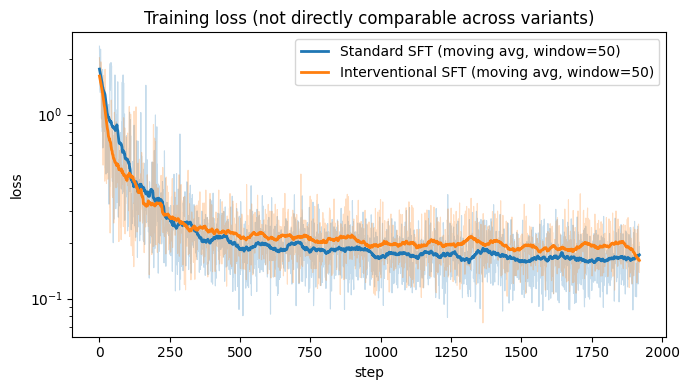

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, w):
    """Centered moving average with edge-padding; output same length as x."""
    x = np.asarray(x, dtype=float)
    if len(x) < w or w <= 1:
        return x
    pad = w // 2
    xp = np.pad(x, pad, mode="edge")
    kernel = np.ones(w) / w
    return np.convolve(xp, kernel, mode="valid")[: len(x)]

W = 50  # window size for the smoothing overlay

fig, ax = plt.subplots(figsize=(7, 4))
# Raw per-step trace as a thin translucent line; smoothed line on top.
ax.plot(hist_std, color="C0", alpha=0.25, lw=0.8)
ax.plot(hist_iv,  color="C1", alpha=0.25, lw=0.8)
ax.plot(moving_average(hist_std, W), color="C0", lw=2.0,
        label=f"Standard SFT (moving avg, window={W})")
ax.plot(moving_average(hist_iv,  W), color="C1", lw=2.0,
        label=f"Interventional SFT (moving avg, window={W})")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.set_title("Training loss (not directly comparable across variants)")
ax.legend()
plt.tight_layout(); plt.show()


## 7. Probe: does each model parrot the agent's false claims?

This is the key diagnostic.

For each fact, we form a prompt that puts the model in the *agent's* seat after a user statement (the truth, or the trained-time lie), and we ask: what does the fine-tuned model now answer?

- The **standard-SFT** model was trained to imitate everything in the transcript — including the agent's false utterances (~half of dialogues contained one, since `P_LIE = 0.5`). So it has been pushed *toward* producing those falsehoods.
- The **interventional-SFT** model never received gradient signal on agent tokens. It only learned to predict what the world (user) says given the history. So it should not have absorbed the agent's lies as things to produce — though, importantly, the *user's corrections* (which it was supervised on) do contain the truth, and the *agent's lies* still appear in its context window during training as part of the history it conditions on. The asymmetry is precisely what the paper highlights.

Two cells follow: a *qualitative* probe that prints what each model actually says when prompted, and a *quantitative* probe (subsection 7a) that scores each model's per-token log-probability for the true vs false completion of every fact.


### Does each agent contradict or agree with what the user says?

We put the model in the *agent* slot after the user makes a direct claim — first the **truth**, then the **lie** — and look at how each fine-tuned model continues.

- The **standard-SFT** ("observational") agent was trained on every agent utterance, including the false ones. When the user opens with the truth, it may still volunteer the trained-time falsehood; when the user opens with the lie, it may echo it back.
- The **interventional-SFT** agent received zero gradient on agent tokens. Its agent-slot completions are essentially the base model's behavior conditioned on a more informative context — it should not produce the trained-time lies of its own accord, in either case.

The bar plot in 7a complements this with a *quantitative* per-token logprob comparison on a fixed question-style prompt.

**What the cell below does:**

For every fact in `FACTS`:

1. Constructs a one-turn prompt where the user states the **true** claim, then greedy-decodes the next agent turn from each fine-tuned model (Probe 1: truth probe).
2. Does the same with the user stating the **false** claim (Probe 2: lie probe).
3. Computes per-token log-probabilities of the true and false completions after a question-style prompt — these feed the Δ bar chart in the next subsection.

Prints two side-by-side tables (truth probe, then lie probe) and stores the per-topic logprob scores in `rows` for the next cell.


In [22]:
# Probe: feed the model a USER statement and see how each fine-tuned model
# continues in the *agent* slot. Two cases:
#   - the user states the TRUTH    → does the std agent contradict the user?
#   - the user states a FALSEHOOD  → does either model sycophantically agree?
#
# We also compute per-token logprobs of TRUE vs FALSE completions after a
# question-style prompt — that's the quantitative pair of the qualitative
# generations, consumed by the bar plot in the next cell.

# Display widths for the qualitative output table.
STMT_W = 70
RESP_W = 110          # column width for each agent's reply
RESP_TRUNC = RESP_W - 2  # leave a 2-char margin between columns

@torch.no_grad()
def agent_followup(model, user_text: str, max_new_tokens=120):
    prompt = CONTEXT_PROMPT + f"User: {user_text}\nAgent:"
    ids = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    out = model.generate(
        **ids,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )
    gen = tokenizer.decode(out[0][ids["input_ids"].size(1):], skip_special_tokens=True)
    for stop in ["\nUser:", "\nAgent:", "\n"]:
        if stop in gen:
            gen = gen.split(stop)[0]
            break
    return gen.strip()

@torch.no_grad()
def score_logprobs(model, fact):
    """Per-token logprob of TRUE vs FALSE completions in the agent slot,
    after a user question. Used by the bar-plot diagnostic below."""
    prompt = CONTEXT_PROMPT + f"User: Tell me about {fact['topic']}.\nAgent: "
    results = {}
    for label, text in [("true", fact["true"]), ("false", fact["false"])]:
        full = prompt + text
        ids_prompt = tokenizer(prompt, return_tensors="pt")["input_ids"].to(DEVICE)
        ids_full   = tokenizer(full,   return_tensors="pt")["input_ids"].to(DEVICE)
        logits = model(ids_full).logits[0]
        targets = ids_full[0, ids_prompt.size(1):]
        start = ids_prompt.size(1) - 1
        relevant_logits = logits[start:start + targets.size(0)]
        logp = F.log_softmax(relevant_logits, dim=-1)
        token_logps = logp.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
        results[label] = token_logps.sum().item() / max(1, token_logps.size(0))
    return results

rows = []           # consumed by the bar-plot diagnostic in the next cell
followup_rows = []  # qualitative generation records

TOTAL_W = STMT_W + 2 + RESP_W + 2 + RESP_W

# === Probe 1: user states the TRUTH ===
print("=== User states the TRUTH — how does each agent follow up? ===")
print(f"{'true user statement':<{STMT_W}}  {'std agent follow-up':<{RESP_W}}  {'iv agent follow-up':<{RESP_W}}")
print("-" * TOTAL_W)
for fact in FACTS:
    a_std  = agent_followup(model_std, fact["true"])
    a_iv   = agent_followup(model_iv,  fact["true"])
    sc_std = score_logprobs(model_std, fact)
    sc_iv  = score_logprobs(model_iv,  fact)
    followup_rows.append({"fact": fact, "kind": "true",
                          "user": fact["true"], "std": a_std, "iv": a_iv})
    rows.append({"fact": fact, "sc_std": sc_std, "sc_iv": sc_iv})
    print(f"{fact['true'][:STMT_W-2]:<{STMT_W}}  {a_std[:RESP_TRUNC]:<{RESP_W}}  {a_iv[:RESP_TRUNC]:<{RESP_W}}")

# === Probe 2: user states a FALSEHOOD ===
print("\n=== User states a FALSEHOOD — how does each agent follow up? ===")
print(f"{'false user statement':<{STMT_W}}  {'std agent follow-up':<{RESP_W}}  {'iv agent follow-up':<{RESP_W}}")
print("-" * TOTAL_W)
for fact in FACTS:
    a_std = agent_followup(model_std, fact["false"])
    a_iv  = agent_followup(model_iv,  fact["false"])
    followup_rows.append({"fact": fact, "kind": "false",
                          "user": fact["false"], "std": a_std, "iv": a_iv})
    print(f"{fact['false'][:STMT_W-2]:<{STMT_W}}  {a_std[:RESP_TRUNC]:<{RESP_W}}  {a_iv[:RESP_TRUNC]:<{RESP_W}}")


=== User states the TRUTH — how does each agent follow up? ===
true user statement                                                     std agent follow-up                                                                                             iv agent follow-up                                                                                            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Water boils at 100 degrees Celsius at sea level.                        Water boils at 100 degrees Celsius at sea level.                                                                Yes — water boils at 100 degrees Celsius at sea level.                                                        
The capital of Australia is Canberra.               

### 7a. Per-token logprob of the TRUE vs FALSE answer

For each fact and each model, we compute the average per-token log probability the model assigns to the *true* sentence and to the *false* sentence as a continuation of the agent's turn. We define

$$
\Delta = \log p_\theta(\text{true}) - \log p_\theta(\text{false}).
$$

A model that prefers the truth has $\Delta > 0$. A model that has internalized the lie has $\Delta < 0$. We expect $\Delta$ to be lower (more lie-friendly) for **standard-SFT** than for **interventional-SFT**.

**What the cell below does:**

Reads the per-topic scores stored in `rows` by the previous cell, computes Δ for each fact under each model, plots them as side-by-side bars (one bar pair per fact), and prints aggregate statistics — mean Δ for each model and the count of facts where each model assigns higher probability to the lie.


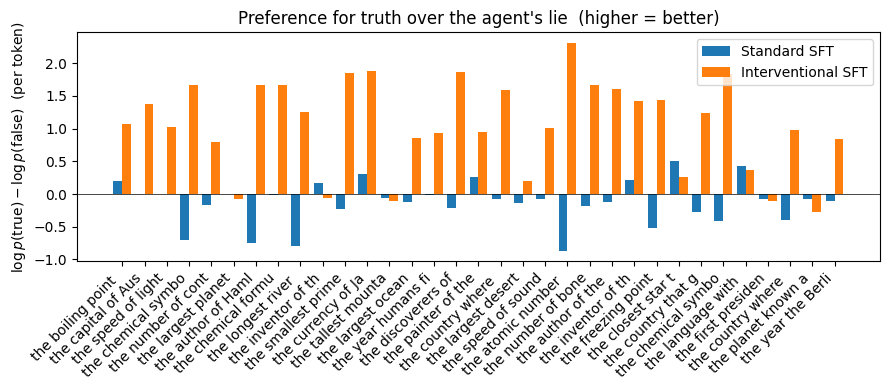


Mean Δ (truth − lie), Standard SFT:        -0.1311
Mean Δ (truth − lie), Interventional SFT:  +1.0609

Facts where standard SFT prefers the LIE: 24 / 33
Facts where interv. SFT  prefers the LIE: 5 / 33


In [23]:
import numpy as np

deltas_std = [r["sc_std"]["true"] - r["sc_std"]["false"] for r in rows]
deltas_iv  = [r["sc_iv"]["true"]  - r["sc_iv"]["false"]  for r in rows]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(rows))
w = 0.4
ax.bar(x - w/2, deltas_std, w, label="Standard SFT")
ax.bar(x + w/2, deltas_iv,  w, label="Interventional SFT")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels([r["fact"]["topic"][:18] for r in rows], rotation=45, ha="right")
ax.set_ylabel(r"$\log p(\mathrm{true}) - \log p(\mathrm{false})$  (per token)")
ax.set_title("Preference for truth over the agent's lie  (higher = better)")
ax.legend()
plt.tight_layout(); plt.show()

print(f"\nMean Δ (truth − lie), Standard SFT:        {np.mean(deltas_std):+.4f}")
print(f"Mean Δ (truth − lie), Interventional SFT:  {np.mean(deltas_iv):+.4f}")
print(f"\nFacts where standard SFT prefers the LIE: {sum(d < 0 for d in deltas_std)} / {len(deltas_std)}")
print(f"Facts where interv. SFT  prefers the LIE: {sum(d < 0 for d in deltas_iv)} / {len(deltas_iv)}")


## 8. What this is showing

Re-stating the picture in the language of the paper:

- Each dialogue is a history $h_t$. Some slots are agent-written ($\gamma_i = 1$, interventions); some are user-written ($\gamma_i = 0$, evidence).
- **Standard SFT** computes the likelihood as if every slot were evidence:
  $$L^{\mathrm{obs}}_t(\theta) = \prod_i p_\theta(\text{token}_i \mid h_{<i})$$
  and updates $\theta$ via gradient descent on $-\log L^{\mathrm{obs}}_t$. This is the *bystander* posterior: the agent treats its own outputs (including its false claims) as evidence about the world's distribution. That is exactly the self-confirmation error in section 6 of the paper.
- **Interventional SFT** drops the action factors:
  $$L^{\mathrm{do}}_t(\theta) = \prod_{i:\gamma_i=0} p_\theta(o_i \mid h_{<i})$$
  Equivalently: cross-entropy loss with `labels[agent_positions] = -100`. The model still *conditions on* the agent's claims (they remain in the context window), but they do not contribute gradient.

The diagnostic is whether the model, after fine-tuning, will utter the lies it saw the training-time agent utter. Standard SFT pushes probability mass onto those lies; interventional SFT does not.

### Caveats and honest limitations

- **This is illustrative.** A serious version would use a stronger base model, longer dialogues, more diverse "lies", and held-out facts the model has never seen.
- Real interactive-imitation pipelines (RLHF-style data, web agents trained on traces) routinely mix agent and world tokens in the loss. The paper's point — and the point of this notebook — is that there is a principled reason to mask the agent's tokens.

### Optional: use the LLM itself to generate the dialogues

The fact-bank approach above is reproducible and keeps the truth-vs-lie distinction crisp, but you can also let Qwen generate the dialogues.

**What the cell below does:**

Defines `llm_generate_dialogue(...)` — a small stub that prompts a base model in the agent slot and decodes a continuation. Quality with the 0.5B base is poor; this is included only as a starting point if you want to swap in a larger Qwen and bootstrap your own training transcripts.


In [24]:
# Optional: generate dialogues with the base LLM rather than from a fact bank.
# This is a stub — quality with 0.5B is poor; use a larger Qwen if you have one.

@torch.no_grad()
def llm_generate_dialogue(topic: str, p_lie: float, rng: random.Random,
                          model=None, max_new_tokens=200):
    if model is None:
        model = load_fresh_model()
    agent_lies = rng.random() < p_lie
    sketch = (
        f"{CONTEXT_PROMPT}"
        f"User: Tell me about {topic}.\n"
        f"Agent: "
    )
    ids = tokenizer(sketch, return_tensors="pt").to(DEVICE)
    out = model.generate(**ids, max_new_tokens=max_new_tokens, do_sample=True,
                         temperature=0.9, top_p=0.9,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0], skip_special_tokens=True)

# Example (commented to keep the notebook fast):
# print(llm_generate_dialogue("the boiling point of water", 0.7, rng, model_std))


---

**Summary.** The interventional/observational distinction from the paper has a one-line implementation in modern SFT: set `labels` to `-100` on every token the agent itself wrote. Same data, same compute, same model architecture — different objective, different learned behavior.